# Feature Engineering

This notebook assembles the ML-ready feature matrix from:
1. DOS features (band edge energies, orbital character, Efermi)

and generates 2 additional sets of features using the MAGPIE preset from matminer
2. composition `ElementProperty`
3. site element specific `ElementProperty`

These three feature sets can be combined or used separately for ML, which informs us about the importance of the features in each set for band gap prediction.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pymatgen.core import Composition, Element
from matminer.featurizers.composition import ElementProperty
from matminer.utils.data import MagpieData, PymatgenData
from scipy.stats import pearsonr

### 1. Load data, which contains DOS features

In [178]:
alloy_df = pd.read_parquet('alloy_df.parquet')
pure_df  = pd.read_parquet('pure_phases_df.parquet')
dos_df   = pd.read_parquet('dos_features.parquet')

print(f'alloy_df:  {alloy_df.shape}  columns: {list(alloy_df.columns)}')
print(f'pure_df:   {pure_df.shape}  columns: {list(pure_df.columns)}')
print(f'dos_df:    {dos_df.shape}  columns: {list(dos_df.columns[:8])} ...')

alloy_df:  (6141, 14)  columns: ['alloy_id', 'A1', 'A2', 'B1', 'B2', 'X', 'x', 'formula', 'formula_0', 'formula_100', 'Eg', 'direct', 'dHf', 'dHd']
pure_df:   (547, 9)  columns: ['formula', 'A1', 'A2', 'B', 'X', 'Eg', 'direct', 'dHf', 'dHd']
dos_df:    (6576, 239)  columns: ['formula', 'is_alloy', 'Efermi', 'vbm_up_energy', 'cbm_up_energy', 'Ag_up_vbm_orb_idx', 'Ag_up_vbm_frac', 'Cs_up_vbm_orb_idx'] ...


In [13]:
# Combine alloy and pure phase targets into one lookup table.
# pure_df uses 'B' column; rename to 'B1' for a consistent schema.
alloy_targets = alloy_df[['formula', 'A1', 'A2', 'B1', 'B2', 'X', 'x', 'Eg', 'dHf', 'dHd']].copy()
alloy_targets['is_alloy'] = True

pure_targets = pure_df[['formula', 'A1', 'A2', 'B', 'X', 'Eg', 'dHf', 'dHd']].copy()
pure_targets = pure_targets.rename(columns={'B': 'B1'})
pure_targets['B2']       = np.nan
pure_targets['x']        = np.nan
pure_targets['is_alloy'] = False

all_targets = pd.concat([alloy_targets, pure_targets], ignore_index=True)#.dropna(subset=['dHd'])
print(f'Combined target table: {all_targets.shape}')
display(all_targets.head(3))
display(all_targets.tail(3))

Combined target table: (6688, 11)


,formula,A1,A2,B1,B2,X,x,Eg,dHf,dHd,is_alloy
0,Rb2Cs2Ti3SrBr12,Rb,Cs,Ti,Sr,Br,25.0,0.0443,-1.648434,0.106158,True
1,RbCsTiSrBr6,Rb,Cs,Ti,Sr,Br,50.0,0.0862,-1.826064,0.078962,True
2,Rb2Cs2TiSr3Br12,Rb,Cs,Ti,Sr,Br,75.0,0.2473,-2.008978,0.044765,True


,formula,A1,A2,B1,B2,X,x,Eg,dHf,dHd,is_alloy
6685,KAgCu2Cl6,K,Ag,Cu,NaN,Cl,NaN,0.0000,-0.965842,0.029983,False
6686,NaRbPb2Br6,Na,Rb,Pb,NaN,Br,NaN,2.5032,-1.401722,0.038925,False
6687,NaCsFe2I6,Na,Cs,Fe,NaN,I,NaN,NaN,NaN,NaN,False


In [ ]:
# Join DOS features onto target table (inner join: only rows with both targets and DOS).
dos_cols = ['vbm_up_energy', 'cbm_up_energy', 'vbm_down_energy', 'cbm_down_energy', 'x_frac', 'formula_0', 'formula_100']
remaining_dos_cols = [c for c in dos_df.columns if c not in dos_cols and c != 'formula' and c != 'is_alloy'] # 'is_alloy' is degenerate between both tables
dos_cols = dos_cols + remaining_dos_cols
ml_df = all_targets.merge(dos_df[['formula'] + dos_cols], on='formula', how='inner')
ml_df.rename(columns={'x': 'x_percent', 'formula_0': 'formula_1-x', 'formula_100': 'formula_x'}, inplace=True)
# rename columns for clarity, formula_x is more intuitive than formula_100 for fraction interpolation

print(f'After DOS join: {ml_df.shape}')
print(f'  Alloy rows:      {ml_df["is_alloy"].sum()}')
print(f'  Pure phase rows: {(~ml_df["is_alloy"]).sum()}')
print(f'  Rows with Eg:    {ml_df["Eg"].notna().sum()}')

After DOS join: (6519, 248)
  Alloy rows:      5992
  Pure phase rows: 527
  Rows with Eg:    6519


## 2. Composition ElementProperty (MAGPIE)

Compute compositions' stoichiometry-weighted **statistics** as features using 22 MAGPIE elemental properties 

Six statistics computed per property: mean, min, max, range, std, mode. (MAGPIE preset defaults)

Total: 22 properties x 6 statistics = **132 features**.

For the formula `AA'(B_{1-x}B'_x)X_6` (e.g. `RbCsTiCrBr6` at x=0.5):
- A-site: Rb, Cs (1 atom each)
- B-site: Ti, Cr (1 atom each)
- X-site: Br (6 atoms)

The X-site dominates stoichiometric averages, diluting B-site signal even though EDA showed B-site identity drives band gap.

In [ ]:
ep = ElementProperty.from_preset('magpie') #simplify feature generation using Magpie preset
print('MAGPIE properties:', ep.features)
print('Statistics:       ', ep.stats)
print(f'Total features:    {len(ep.features) * len(ep.stats)}')

MAGPIE properties: ['Number', 'MendeleevNumber', 'AtomicWeight', 'MeltingT', 'Column', 'Row', 'CovalentRadius', 'Electronegativity', 'NsValence', 'NpValence', 'NdValence', 'NfValence', 'NValence', 'NsUnfilled', 'NpUnfilled', 'NdUnfilled', 'NfUnfilled', 'NUnfilled', 'GSvolume_pa', 'GSbandgap', 'GSmagmom', 'SpaceGroupNumber']
Statistics:        ['minimum', 'maximum', 'range', 'mean', 'avg_dev', 'mode']
Total features:    132


In [68]:
# Demo: featurize a single formula to inspect the output structure.
demo_formula = 'RbCsTiCrBr6'
feat_vals  = ep.featurize(Composition(demo_formula))
feat_names = ep.feature_labels()

demo = pd.Series(feat_vals, index=feat_names)
print(f'Features for {demo_formula} (first 12):')
print(demo.head(12))

Features for RbCsTiCrBr6 (first 12):
MagpieData minimum Number             22.00
MagpieData maximum Number             55.00
MagpieData range Number               33.00
MagpieData mean Number                34.80
MagpieData avg_dev Number              4.72
MagpieData mode Number                35.00
MagpieData minimum MendeleevNumber     4.00
MagpieData maximum MendeleevNumber    95.00
MagpieData range MendeleevNumber      91.00
MagpieData mean MendeleevNumber       67.10
MagpieData avg_dev MendeleevNumber    33.48
MagpieData mode MendeleevNumber       95.00
dtype: float64


In [ ]:
# Featurize the full dataset.
# ep.featurize_dataframe needs a pymatgen Composition column.
ml_df_A = ml_df.copy()
ml_df_A['composition'] = ml_df_A['formula'].apply(Composition) #apply Composition function to the 'formula' column
ml_df_A = ep.featurize_dataframe(ml_df_A, col_id='composition', ignore_errors=True) #featurize function but to dataframe column

magpie_cols_A = [c for c in ml_df_A.columns if 'MagpieData' in c]
print(f'Shape after Option A featurization: {ml_df_A.shape}')
print('Example columns:', magpie_cols_A[:6])

ElementProperty:   0%|          | 0/6519 [00:00<?, ?it/s]

Shape after Option A featurization: (6519, 381)
Example columns: ['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number']


In [72]:
nan_rate_A = ml_df_A[magpie_cols_A].isna().mean().sort_values(ascending=False)
print('Option A columns with any NaN:')
print(nan_rate_A[nan_rate_A > 0])

Option A columns with any NaN:
Series([], dtype: float64)


Using MAGPIE preset:
- Simple to run: no domain knowledge needed, works on any formula string.
- Statistics mix A-site, B-site, and X-site contributions proportionally to stoichiometry.
- The Br/I/Cl/F dominance (6 atoms) means `mean_Electronegativity` mostly reflects the halide, not the B-site.
- Loses information about *which site* a property comes from — B1 and B2 are indistinguishable once averaged.
- Good as a **baseline** or for comparison with other physics informed feature sets.

## 3. Site specific elemental properties

MAGPIE properties **for each crystallographic site** (B1, B2, X) using `MagpieData`, as opposed to preset statistics.
Properties are chosen based on physical relevance to band gap:

| Property | Physical relevance |
|---|---|
| `NdValence` | valence d-electron count; key for TM band gap behavior |
| `NValance` | total valence electrons; band edge character |
| `Electronegativity` | controls charge transfer, gap width, and covalent mixing |
| `AtomicRadius` | size mismatch drives structural distortion |
| `GSbandgap` | elemental reference gap (0 for metals) |
| `GSmagmom` | ground-state magnetic moment; spin polarization |
| `MeltingT` | bond strength / cohesive energy proxy |

Total: 7 properties x 5 sites (A1, A2, B1, B2, X) + x_frac = **35 features**.

In [180]:
magpie = MagpieData()

SITE_PROPERTIES = [
    'NdValence',
    'NValence',
    'Electronegativity',
    'AtomicRadius',
    'GSbandgap',
    'GSmagmom',
    'MeltingT',
]

def lookup_elem_prop(el_symbol, prop):
    """Return scalar MAGPIE property for one element; NaN if lookup fails."""
    try:
        return magpie.get_elemental_property(Element(el_symbol), prop)
    except Exception:
        return np.nan

# Demo: inspect Ti properties
print('Ti site properties:')
for prop in SITE_PROPERTIES:
    print(f'  {prop:22s} = {lookup_elem_prop("Ti", prop)}')

Ti site properties:
  NdValence              = 2.0
  NValence               = 4.0
  Electronegativity      = 1.54
  AtomicRadius           = 1.4
  GSbandgap              = 0.0
  GSmagmom               = 2.25333333333e-05
  MeltingT               = 1941.0


In [181]:
lookup_elem_prop('Br', 'NValence')

17.0

In [182]:
ml_df_B = ml_df.copy()

# Per-site lookup for A1, A2,B1, B2, X.
# B2 (and sometimes A2) is NaN for pure phases -> those rows get NaN B2 features (handled in NaN section).
for site, col in [('A1', 'A1'), ('A2', 'A2'), ('B1', 'B1'), ('B2', 'B2'), ('X', 'X')]:
    for prop in SITE_PROPERTIES:
        ml_df_B[f'{site}_{prop}'] = ml_df_B[col].apply(
            lambda el: lookup_elem_prop(el, prop) if pd.notna(el) else np.nan
        ) #lambda used here because the function we apply takes two arguments instead of one

# not needed anymore as we have the x_frac column from DOS join
# # Convert x (25/50/75) to x_frac (0.25/0.50/0.75); NaN for pure phases.
# ml_df_B['x_frac'] = ml_df_B['x'] / 100 

site_feat_cols = [f'{s}_{p}' for s in ['A1', 'A2', 'B1', 'B2', 'X'] for p in SITE_PROPERTIES] + ['x_frac']
print(f'Option B features ({len(site_feat_cols)}): {site_feat_cols}')

Option B features (36): ['A1_NdValence', 'A1_NValence', 'A1_Electronegativity', 'A1_AtomicRadius', 'A1_GSbandgap', 'A1_GSmagmom', 'A1_MeltingT', 'A2_NdValence', 'A2_NValence', 'A2_Electronegativity', 'A2_AtomicRadius', 'A2_GSbandgap', 'A2_GSmagmom', 'A2_MeltingT', 'B1_NdValence', 'B1_NValence', 'B1_Electronegativity', 'B1_AtomicRadius', 'B1_GSbandgap', 'B1_GSmagmom', 'B1_MeltingT', 'B2_NdValence', 'B2_NValence', 'B2_Electronegativity', 'B2_AtomicRadius', 'B2_GSbandgap', 'B2_GSmagmom', 'B2_MeltingT', 'X_NdValence', 'X_NValence', 'X_Electronegativity', 'X_AtomicRadius', 'X_GSbandgap', 'X_GSmagmom', 'X_MeltingT', 'x_frac']


In [183]:
nan_rate_B = ml_df_B[site_feat_cols].isna().mean().sort_values(ascending=False)
print('Option B NaN rates:')
print(nan_rate_B)

Option B NaN rates:
A2_GSbandgap            0.463261
A2_GSmagmom             0.463261
A2_NdValence            0.463261
A2_NValence             0.463261
A2_Electronegativity    0.463261
A2_AtomicRadius         0.463261
A2_MeltingT             0.463261
B2_Electronegativity    0.080841
B2_AtomicRadius         0.080841
B2_GSbandgap            0.080841
B2_GSmagmom             0.080841
B2_MeltingT             0.080841
x_frac                  0.080841
B2_NValence             0.080841
B2_NdValence            0.080841
X_NValence              0.000000
X_NdValence             0.000000
X_Electronegativity     0.000000
X_AtomicRadius          0.000000
X_GSbandgap             0.000000
X_GSmagmom              0.000000
X_MeltingT              0.000000
A1_NdValence            0.000000
B1_MeltingT             0.000000
B1_GSmagmom             0.000000
A1_NValence             0.000000
B1_AtomicRadius         0.000000
B1_Electronegativity    0.000000
B1_NValence             0.000000
B1_NdValence           

In [184]:
# Confirm B2 NaN is exclusively pure phases (expected).
b2_nan_rows = ml_df_B[ml_df_B['B2_NdValence'].isna()]
print(f'Rows with B2_NdValence NaN: {len(b2_nan_rows)}')
print(f'  Pure phases:  {(~b2_nan_rows["is_alloy"]).sum()}')
print(f'  Alloys:       {b2_nan_rows["is_alloy"].sum()}')

Rows with B2_NdValence NaN: 527
  Pure phases:  527
  Alloys:       0


**x_frac decision**

`x_frac` (B-site mixing ratio 0.25/0.50/0.75) has direct physical meaning: it controls the B1/B2 character at the band edges.
Pure phases have no mixing ratio (`x_frac = NaN`).

Options:
- Assign `x_frac = 0` for all pure phases (treated as x=0 endpoint)
- Train on alloys only and use pure phases properties as features

Below: assign `x_frac = 0` for simplicity. The pure-phase B2 assignment (B2=B1) is consistent with this.

# Continue here

## 4. Assemble full feature matrix (Option B + DOS features)

Note we did not remove element vbm and cbm contribution, which are information classified under target-leakage as these information are only attainable from having run DFT (which defeats the purpose of ML here). This is to establish an estimated upper bound performance ML (empirical in this case, not theoretical) can achieve, with the intention of comparing how the model performance changes when part or all of the band edge contributions are removed.

In [131]:
# DOS feature columns: all dos_df columns except identifiers and target-leakage columns.
EXCLUDE_DOS = {
    'formula', 'is_alloy',
    'bg_energy', 'bg_direct', 'bg_transition',  # DOS-derived gap ~ DFT Eg: target leakage
    'vbm_up_energy', 'cbm_up_energy', 'vbm_down_energy', 'cbm_down_energy', 'cbm_dft', 'vbm_dft', # DOS band edge energies: target leakage
    'x_frac', 'formula_0', 'formula_100',        # compositional metadata already in all_targets
}
dos_feat_cols = [c for c in dos_cols if c not in EXCLUDE_DOS]
print(f'DOS feature columns: {len(dos_feat_cols)}')
print(dos_feat_cols[:10], '...')

DOS feature columns: 225
['Efermi', 'Ag_up_vbm_orb_idx', 'Ag_up_vbm_frac', 'Cs_up_vbm_orb_idx', 'Cs_up_vbm_frac', 'Cd_up_vbm_orb_idx', 'Cd_up_vbm_frac', 'Co_up_vbm_orb_idx', 'Co_up_vbm_frac', 'F_up_vbm_orb_idx'] ...


In [132]:
ml_df_B['vbm_dft']

0       None
1       None
2       None
3       None
4       None
        ... 
6514    None
6515    None
6516    None
6517    None
6518    None
Name: vbm_dft, Length: 6519, dtype: object

In [155]:
ALL_FEATURE_COLS = dos_feat_cols + site_feat_cols #site_feat_cols defined in earlier cell

feat_df = ml_df_B[
    ['formula', 'A1', 'A2', 'B1', 'B2', 'X', 'is_alloy', 'x_frac', 'Eg', 'dHf', 'dHd']
    # + ALL_FEATURE_COLS
    + [feat for feat in ALL_FEATURE_COLS if feat not in ['formula', 'A1', 'A2', 'B1', 'B2', 'X', 'is_alloy', 'x_frac', 'Eg', 'dHf', 'dHd']]
].copy()
feat_df = feat_df[feat_df['Eg'].notna()].reset_index(drop=True)

print(f'Feature matrix: {feat_df.shape}')
print(f'  Rows with valid Eg:  {len(feat_df)}')
print(f'  Feature columns:     {len(ALL_FEATURE_COLS)}')

Feature matrix: (6519, 257)
  Rows with valid Eg:  6519
  Feature columns:     247


## 5. NaN audit and imputation

In [156]:
nan_summary = feat_df[ALL_FEATURE_COLS].isna().sum().sort_values(ascending=False)
print(f'Columns with NaN ({(nan_summary > 0).sum()} total):')
print(nan_summary[nan_summary > 0].head(30))

Columns with NaN (232 total):
Li_down_vbm_frac       6509
Li_down_cbm_frac       6509
Li_up_vbm_orb_idx      6509
Li_up_vbm_frac         6509
Li_up_cbm_orb_idx      6509
Li_up_cbm_frac         6509
Li_down_vbm_orb_idx    6509
Li_down_cbm_orb_idx    6509
Pt_down_vbm_orb_idx    6475
Pt_down_vbm_frac       6475
Pt_down_cbm_orb_idx    6475
Pt_down_cbm_frac       6475
Pt_up_cbm_orb_idx      6475
Pt_up_vbm_frac         6475
Pt_up_cbm_frac         6475
Pt_up_vbm_orb_idx      6475
Ag_up_cbm_frac         6386
Ag_up_cbm_orb_idx      6386
Ag_up_vbm_orb_idx      6386
Ag_down_vbm_orb_idx    6386
Ag_down_vbm_frac       6386
Ag_up_vbm_frac         6386
Ag_down_cbm_frac       6386
Ag_down_cbm_orb_idx    6386
Pd_down_cbm_orb_idx    6373
Pd_up_vbm_orb_idx      6373
Pd_up_vbm_frac         6373
Pd_down_cbm_frac       6373
Pd_up_cbm_orb_idx      6373
Pd_down_vbm_frac       6373
dtype: int64


In [157]:
any_nan_mask = feat_df[ALL_FEATURE_COLS].isna().any(axis=1)
print(f'Rows with any NaN feature: {any_nan_mask.sum()} / {len(feat_df)} ({100*any_nan_mask.mean():.1f}%)')
feat_df[any_nan_mask][['formula', 'B1', 'B2', 'X', 'x_frac', 'Eg']].head(10)

Rows with any NaN feature: 6519 / 6519 (100.0%)


,formula,B1,B2,X,x_frac,Eg
0,Rb2Cs2Ti3SrBr12,Ti,Sr,Br,0.25,0.0443
1,RbCsTiSrBr6,Ti,Sr,Br,0.50,0.0862
2,Rb2Cs2TiSr3Br12,Ti,Sr,Br,0.75,0.2473
3,Rb4Fe3CoI12,Fe,Co,I,0.25,0.0163
4,Rb2FeCoI6,Fe,Co,I,0.50,0.0000
5,Rb4FeCo3I12,Fe,Co,I,0.75,0.0000
6,Rb2Cs2Mn3CoI12,Mn,Co,I,0.25,0.0000
7,RbCsMnCoI6,Mn,Co,I,0.50,0.0000
8,Rb2Cs2MnCo3I12,Mn,Co,I,0.75,0.0000
9,Rb2Cs2Mg3CaCl12,Mg,Ca,Cl,0.25,4.4273


In [158]:
# Separate NaN sources for diagnosis.
b2_cols    = [c for c in ALL_FEATURE_COLS if c.startswith('B2_')]
other_cols = [c for c in ALL_FEATURE_COLS if c not in b2_cols + ['x_frac']]

print(f'NaN in B2 features (pure phases, expected):  {feat_df[b2_cols].isna().any(axis=1).sum()}')
print(f'NaN in x_frac (pure phases, expected):       {feat_df["x_frac"].isna().sum()}')
print(f'NaN in remaining (DOS / B1 / X features):    {feat_df[other_cols].isna().any(axis=1).sum()}')

NaN in B2 features (pure phases, expected):  527
NaN in x_frac (pure phases, expected):       527
NaN in remaining (DOS / B1 / X features):    6519


In [159]:
# Impute pure phase B2 features: set B2_* = B1_* (single B site, x=0 endpoint).
for prop in SITE_PROPERTIES:
    feat_df[f'B2_{prop}'] = feat_df[f'B2_{prop}'].fillna(feat_df[f'B1_{prop}'])

# Impute x_frac = 0 for pure phases.
feat_df['x_frac'] = feat_df['x_frac'].fillna(0.0)

remaining_nan = feat_df[ALL_FEATURE_COLS].isna().sum().sum()
print(f'Remaining NaN after imputation: {remaining_nan}')
if remaining_nan > 0:
    rc = feat_df[ALL_FEATURE_COLS].isna().sum()
    print(rc[rc > 0])

Remaining NaN after imputation: 1227872
Ag_up_vbm_orb_idx      6386
Ag_up_vbm_frac         6386
Cs_up_vbm_orb_idx      3163
Cs_up_vbm_frac         3163
Cd_up_vbm_orb_idx      5619
                       ... 
Na_up_cbm_frac         5906
Na_down_vbm_orb_idx    5906
Na_down_vbm_frac       5906
Na_down_cbm_orb_idx    5906
Na_down_cbm_frac       5906
Length: 224, dtype: int64


**Remaining NaN (if any):**  
These come from DOS features where a spin channel has no band edge (metallic or half-metallic systems).  
Strategy deferred to the modelling step: tree-based models (XGBoost, LightGBM, sklearn HistGradientBoosting) handle NaN natively. Linear/NN models will need median imputation.

## 6. Feature matrix summary

In [160]:
print('=== Feature matrix summary ===')
print(f'  Total rows:       {len(feat_df)}')
print(f'  Total features:   {len(ALL_FEATURE_COLS)}')
print(f'    DOS features:   {len(dos_feat_cols)}')
print(f'    Site features:  {len(site_feat_cols)}')
print(f'  Metallic (Eg=0):  {(feat_df["Eg"] == 0).sum()}')
print()
print(feat_df['Eg'].describe())

=== Feature matrix summary ===
  Total rows:       6519
  Total features:   247
    DOS features:   225
    Site features:  22
  Metallic (Eg=0):  2049

count    6519.000000
mean        1.103078
std         1.566279
min         0.000000
25%         0.000000
50%         0.261900
75%         1.815500
max         7.055200
Name: Eg, dtype: float64


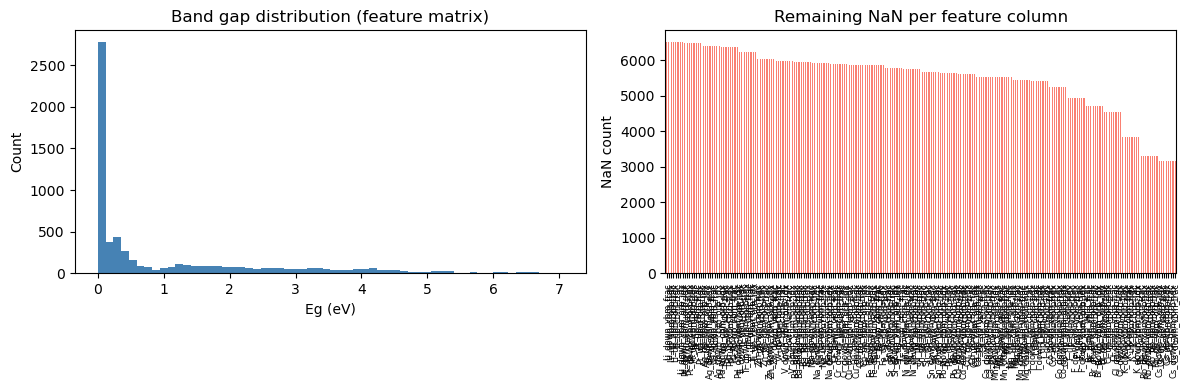

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(feat_df['Eg'], bins=60, edgecolor='none', color='steelblue')
axes[0].set_xlabel('Eg (eV)')
axes[0].set_ylabel('Count')
axes[0].set_title('Band gap distribution (feature matrix)')

nan_per_col = feat_df[ALL_FEATURE_COLS].isna().sum().sort_values(ascending=False)
nan_per_col = nan_per_col[nan_per_col > 0]
if len(nan_per_col) > 0:
    nan_per_col.plot(kind='bar', ax=axes[1], color='salmon')
    axes[1].set_title('Remaining NaN per feature column')
    axes[1].set_ylabel('NaN count')
    axes[1].tick_params(axis='x', labelsize=6)
else:
    axes[1].text(0.5, 0.5, 'No remaining NaN', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Remaining NaN per feature column')

plt.tight_layout()
plt.show()

In [162]:
feat_df.to_parquet('feature_matrix.parquet', index=False)
feat_df.to_csv('feature_matrix.csv', index=False)
print(f'Saved feature_matrix.parquet + feature_matrix.csv  ({feat_df.shape})')

Saved feature_matrix.parquet + feature_matrix.csv  ((6519, 257))


## 7. Option A vs Option B: Pearson r comparison

Check whether per-site features (Option B) capture stronger linear correlations with Eg than full-composition statistics (Option A).
Note: Pearson r has the same limitations as in EDA — TM step-like behavior will still appear as low r.

In [ ]:
def top_bottom_pearson(df, feat_cols, target='Eg', n=10, min_samples=50):
    results = {}
    for col in feat_cols:
        sub = df[[target, col]].dropna()
        if len(sub) < min_samples:
            continue
        r, _ = pearsonr(sub[target], sub[col])
        results[col] = r
    s = pd.Series(results, name='r')
    top    = s.sort_values(key=abs, ascending=False).reset_index().head(n)
    bottom = s.sort_values(key=abs, ascending=True).reset_index().head(n)
    output_df = pd.DataFrame({
        'feature_top': top['index'],
        'r_top': top['r'],
        'feature_bottom': bottom['index'],
        'r_bottom': bottom['r']
    })
    return output_df

print('=== Option B: top/bottom site features by Pearson r ===')
display(top_bottom_pearson(feat_df, site_feat_cols))
print()
print('=== Option A: top/bottom MAGPIE statistics by Pearson r ===')
ml_df_A_Eg = ml_df_A[['Eg'] + magpie_cols_A].dropna(subset=['Eg'])
display(top_bottom_pearson(ml_df_A_Eg, magpie_cols_A))

=== Option B: top/bottom site features by Pearson r ===
            feature_top     r_top        feature_bottom  r_bottom
0           B1_MeltingT -0.579180           B2_NValence -0.022316
1       B1_AtomicRadius  0.504172                x_frac -0.072532
2  B1_Electronegativity -0.493376           X_GSbandgap  0.113847
3       B2_AtomicRadius  0.360266           X_NdValence -0.189951
4          B1_NdValence -0.342837            X_NValence -0.189951
5           B1_GSmagmom -0.331118          B2_NdValence -0.202823
6           B2_MeltingT -0.310528            X_MeltingT -0.230466
7           B1_NValence -0.272693  B2_Electronegativity -0.239855
8           B2_GSmagmom -0.260431        X_AtomicRadius -0.245882
9   X_Electronegativity  0.248717   X_Electronegativity  0.248717

=== Option A: top/bottom MAGPIE statistics by Pearson r ===


,feature_top,r_top,feature_bottom,r_bottom
0,MagpieData maximum MeltingT,-0.720692,MagpieData mean GSvolume_pa,0.006062
1,MagpieData range MeltingT,-0.671944,MagpieData minimum Column,-0.009491
2,MagpieData mean MeltingT,-0.572812,MagpieData range Column,0.009491
3,MagpieData maximum NdUnfilled,-0.535689,MagpieData minimum NValence,-0.009928
4,MagpieData range NdUnfilled,-0.535689,MagpieData maximum SpaceGroupNumber,0.010787
5,MagpieData avg_dev NdUnfilled,-0.502376,MagpieData range NValence,-0.013358
6,MagpieData avg_dev MeltingT,-0.497414,MagpieData maximum NValence,-0.013486
7,MagpieData mean NdUnfilled,-0.491662,MagpieData minimum MendeleevNumber,0.017600
8,MagpieData mean NUnfilled,-0.472179,MagpieData minimum Electronegativity,-0.042601
9,MagpieData minimum GSvolume_pa,0.436874,MagpieData avg_dev NValence,-0.046684


## 8. Pending decisions

- [ ] **DOS NaN imputation**: median fill (scikit-learn `SimpleImputer`) vs use tree models that handle NaN natively (XGBoost, LightGBM, `HistGradientBoostingRegressor`)
- [ ] **Categorical encoding**: `orb_idx` (0/1/2/-1) is already integer and works for tree models; one-hot or embeddings needed for linear/NN models
- [ ] **Train set scope**: alloys + pure phases together, or alloys only
- [ ] **Option A vs B ablation**: carry both into baseline modelling and compare
- [ ] **Metal/semiconductor split**: single regression vs two-stage classifier + regressor (deferred from EDA)